In [1]:
import sys
import glob
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import datetime
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr

import warnings
warnings.filterwarnings('ignore')

In [2]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
dataf = "/Users/ellendyer/Documents/GitHub/F4R_data/"

In [3]:
def h2o_conversion(h2o_column):
   #molec/cm**2
   #cm**2 --> kg
   #(pressure in Pa)*( area in m**2)/(gravity in m/s**2)
   P = 101300 #should this be 101325? 
   A = 10**(-4)
   g = 9.81 
   conv_denom = P*A/g 
   
   #molec --> g
   #(number of molecules)*(atomic weight in g/mol)/(avogadro number in molec/mol)
   #AW = 18.015
   AW = 28.97 #g/mol dry air
   AV = 6.02214076*10**23
   conv_enum = h2o_column*AW/AV
   h2o_vmr = conv_enum/conv_denom
   
   return h2o_vmr

def hdo_conversion(hdo_column):
   #molec/cm**2
   #cm**2 --> kg
   #(pressure in Pa)*( area in m**2)/(gravity in m/s**2)
   P = 101300 #should this be 101325? 
   A = 10**(-4)
   g = 9.81 
   conv_denom = P*A/g 
   
   #molec --> g
   #(number of molecules)*(atomic weight in g/mol)/(avogadro number in molec/mol)
   #AW = 19.0214
   AW = 28.97 #g/mol dry air
   AV = 6.02214076*10**23
   conv_enum = hdo_column*AW/AV
   hdo_vmr = conv_enum/conv_denom
   
   return hdo_vmr

def quality_filter(dataset,flag_val):
    
    dataset_out = dataset.where(dataset['hdo_column_number_density_validity']>=flag_val,drop=True)
    
    return dataset_out

def calc_deltad(hdo_vmr,h2o_vmr):
    
    # calculate deltaD
    R = hdo_vmr/h2o_vmr
    # use this RSMOW for molecules of water
    Rvsmow = 3.11*10**(-4)
    dD = (R/Rvsmow - 1)*1000.
    
    return dD

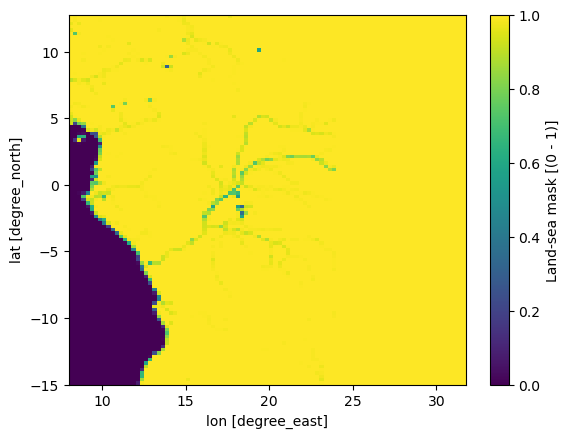

<Figure size 640x480 with 0 Axes>

In [4]:
mask = xr.open_dataset("/Users/ellendyer/Documents/GitHub/f4r-bulk-recycling-model/lsm_1279l4_0.1x0.1.grb_v4_unpack.nc")['lsm']
mask = mask.rename({'latitude':'lat','longitude':'lon'})
mask = mask.squeeze(['time'], drop=True)
mask = mask.where(mask.lon<24.0,1)

hdo_test = xr.open_dataset('/Volumes/Book/HDO_L3/S5P_PAL__L3__HDO__S_20180430T102851_20180430T121021_02824_01_100300_20250307T210309.nc')
hdo_test = hdo_test.rename({'latitude':'lat','longitude':'lon','datetime_start':'time'})
mask_land = mask.interp(lat=hdo_test['lat'],lon=hdo_test['lon'],method='linear',kwargs={"fill_value": "extrapolate"})

mask_land.plot()
plt.show()
plt.clf()

In [ ]:
Y1=2018
Y2=2020

hdo_all_list = []
hdo_all_day_list = []
for Y in range(Y1,Y2+1):
    pathlist = glob.glob(f'/Volumes/Book/HDO_L3/S5P_PAL__L3__HDO__S_{Y}*')
    files_list = []
    for i in pathlist:
        hdoin = xr.open_dataset(i,drop_variables=['datetime_stop'])
        hdoin = hdoin.rename({'latitude':'lat','longitude':'lon','datetime_start':'time'})
        hdoin = hdoin.assign_coords({"time": hdoin.time})
        
        hdoin =  hdoin.where(mask_land!=0.0)
        #hdoin['h2o_column_number_density'].plot()
        #plt.show()
        #plt.clf()
        
        if len(hdoin.lon.values)>0:
           hdoin = hdoin.sortby('time')
           hdoin = hdoin.sel(lat=slice(-15,12),lon=slice(8,31),drop=True).load()
           hdoin['h2o_vmr'] = h2o_conversion(hdoin['h2o_column_number_density'])
           hdoin['hdo_vmr'] = hdo_conversion(hdoin['hdo_column_number_density'])
           hdoin['deltaD'] = calc_deltad(hdoin['hdo_vmr'],hdoin['h2o_vmr'])
           hdo_select = hdoin[['deltaD','h2o_vmr']]
           files_list.append(hdo_select)
        hdoin.close()
        hdo_select.close()
    hdo = xr.concat(files_list,dim='time') 
    hdo_year_list = []
    for m in range(1,13):
        try:
            print(m)
            mp = hdo.sel(time=(hdo.time.dt.month==m), drop=True)
            bins = [datetime.datetime(Y, m, 1),datetime.datetime(Y, m, 10),datetime.datetime(Y, m, 20),datetime.datetime(Y, m, mp.time.dt.days_in_month.values[0])]
            print(bins)
            mp_out = mp.groupby_bins('time', bins,labels=[datetime.datetime(Y, m, 10),datetime.datetime(Y, m, 20),datetime.datetime(Y, m, mp.time.dt.days_in_month.values[0])]).mean()
            mp_out = mp_out.rename({'time_bins':'time'})
            hdo_year_list.append(mp_out)
        except:
            print('no month - ',m,' for year - ',Y)
    hdo_year = xr.concat(hdo_year_list,dim='time')
    hdo_all_list.append(hdo_year)
    hdo_all_day_list.append(hdo)
    hdo.close()
    print('done - ',Y)
hdo_all = xr.concat(hdo_all_list,dim='time')
hdo_all_day = xr.concat(hdo_all_day_list,dim='time')
hdo_all = hdo_all.sel(time=slice('2018-07-01','2024-12-31'))
hdo_all_day = hdo_all_day.dropna(dim='time',how='all')
hdo_all_day = hdo_all_day.sel(time=slice('2018-07-01','2024-12-31'))
print(hdo_all)
print(hdo_all.time)
    
hdo_all.to_netcdf(dataf+'hdo_10day_reg_regrid.nc',engine='h5netcdf')
hdo_all_day.to_netcdf(dataf+'hdo_day_reg_regrid.nc',engine='h5netcdf')
        

1
[datetime.datetime(2018, 1, 1, 0, 0), datetime.datetime(2018, 1, 10, 0, 0), datetime.datetime(2018, 1, 20, 0, 0), datetime.datetime(2018, 1, 31, 0, 0)]
no month -  1  for year -  2018
2
no month -  2  for year -  2018
3
no month -  3  for year -  2018
4
[datetime.datetime(2018, 4, 1, 0, 0), datetime.datetime(2018, 4, 10, 0, 0), datetime.datetime(2018, 4, 20, 0, 0), datetime.datetime(2018, 4, 30, 0, 0)]
no month -  4  for year -  2018
5
[datetime.datetime(2018, 5, 1, 0, 0), datetime.datetime(2018, 5, 10, 0, 0), datetime.datetime(2018, 5, 20, 0, 0), datetime.datetime(2018, 5, 31, 0, 0)]
6
[datetime.datetime(2018, 6, 1, 0, 0), datetime.datetime(2018, 6, 10, 0, 0), datetime.datetime(2018, 6, 20, 0, 0), datetime.datetime(2018, 6, 30, 0, 0)]
7
[datetime.datetime(2018, 7, 1, 0, 0), datetime.datetime(2018, 7, 10, 0, 0), datetime.datetime(2018, 7, 20, 0, 0), datetime.datetime(2018, 7, 31, 0, 0)]
8
[datetime.datetime(2018, 8, 1, 0, 0), datetime.datetime(2018, 8, 10, 0, 0), datetime.datetime(20